In [5]:
pip install sparclclient

  Using cached sparclclient-1.2.8-py2.py3-none-any.whl.metadata (675 bytes)
  Using cached requests-2.31.0-py3-none-any.whl.metadata (4.6 kB)
  Using cached spectres-2.2.2-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached sparclclient-1.2.8-py2.py3-none-any.whl (120 kB)
Using cached requests-2.31.0-py3-none-any.whl (62 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 32.5 MB/s  0:00:00
Using cached spectres-2.2.2-py2.py3-none-any.whl (19 kB)
  Attempting uninstall: requests
    Found existing installation: requests 2.32.5
    Uninstalling requests-2.32.5:
      Successfully uninstalled requests-2.32.5
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.2
    Uninstalling numpy-2.4.2:
      Successfully uninstalled numpy-2.4.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [sparclclient] [numpy]
Note: you may need to restart the kernel to use updated packages.


In [6]:
# ==============================
# Imports
# ==============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from alerce.core import Alerce
from sparcl.client import SparclClient
import warnings

In [7]:
# ==============================
# Initialize clients
# ==============================
alerce_client = Alerce()
sparcl_client = SparclClient()

announcement=Data set deprecation notice: on November 19, 2025 the SDSS/BOSS DR16 data sets were deprecated. Please use the new SDSS/BOSS DR17 data sets instead.


In [8]:
# ==============================
# Objects: TARGETIDs + ZTF OIDs + Redshifts
# ==============================
objects = pd.DataFrame({
    'TARGETID': [
        39627764151619120, 39633408468454516, 39627902957912300,
        39628346086131599, 39627939041510701, 39633413543562464,
        39627806405036766, 39627781784471770, 39633118805624111,
        39633290071641162, 39627782380067362, 39633158374688229
    ],
    'oid': [
        "ZTF20abeojsh", "ZTF19aapfxkt", "ZTF21aaiskhf", "ZTF24aaivkzw",
        "ZTF19aapahga", "ZTF18aaukatc", "ZTF20aadcbak", "ZTF19aadnutn",
        "ZTF20aazpgya", "ZTF20aajcrca", "ZTF23aabfcdi", "ZTF18abeiiwk"
    ],
    'redshift': [
        0.05, 0.12, 0.08, 0.10, 0.07, 0.15, 0.06, 0.09, 0.11, 0.14, 0.05, 0.08
    ]
})

In [9]:
# ==============================
# Emission lines and windows
# ==============================
LINES = {'Hα': 6563, 'Hβ': 4861, '[O III]': 5007}
WINDOW = 10  # +/- 10 Å

In [10]:
# ==============================
# Functions
# ==============================
def plot_light_curve(lc_df, title=''):
    plt.figure(figsize=(5,3))
    for fid in [1,2]:
        fid_df = lc_df[lc_df.fid==fid]
        if len(fid_df)==0:
            continue
        plt.errorbar(fid_df.mjd, fid_df.magpsf, yerr=fid_df.sigmapsf,
                     fmt='*', c={1:'#56e03a',2:'#d42f4b'}[fid], label=f'fid={fid}')
    plt.gca().invert_yaxis()
    plt.xlabel('MJD')
    plt.ylabel('mag')
    plt.title(title)
    plt.legend()
    plt.tight_layout()

def get_spectrum(targetid):
    res = sparcl_client.find(outfields=['sparcl_id'], constraints={'targetid':[targetid]}, limit=1)
    if len(res.ids)==0:
        return None, None, None
    spec = sparcl_client.retrieve([res.ids[0]], include=['flux','ivar','wavelength','wavemin','wavemax','wave_sigma'])
    rec = spec.records[0]
    flux = np.array(rec['flux'])
    ivar = np.array(rec['ivar'])

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        sigma = np.where(ivar>0, 1/np.sqrt(ivar), np.nan)
    
    if 'wavelength' in rec:
        wave = np.array(rec['wavelength'])
    else:
        wave = np.arange(rec['wavemin'], rec['wavemax'], rec['wave_sigma'])[:len(flux)]
    return wave, flux, sigma

def compute_variability(lc_df):
    mags = lc_df['magpsf'].values
    if len(mags)==0:
        return np.nan, np.nan
    amplitude = np.max(mags) - np.min(mags)
    stddev = np.std(mags)
    return amplitude, stddev

def measure_line_peak(wave, flux, redshift, line_name):
    if wave is None or flux is None:
        return np.nan
    obs_wave = LINES[line_name] * (1 + redshift)
    window = (wave > obs_wave - WINDOW) & (wave < obs_wave + WINDOW)
    if not np.any(window):
        return np.nan
    return flux[window].max()

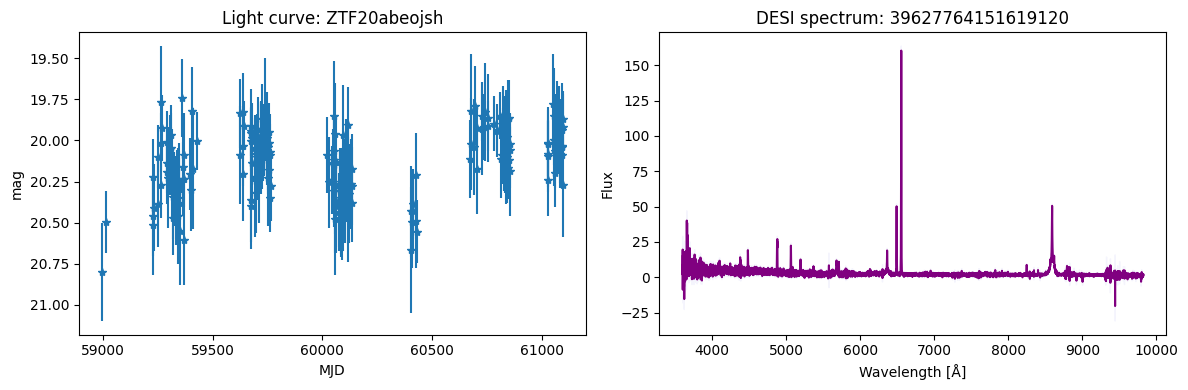

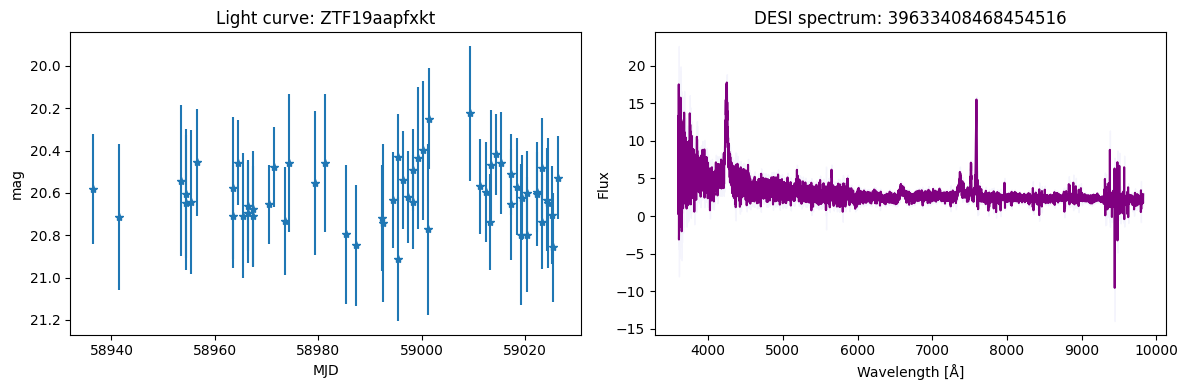

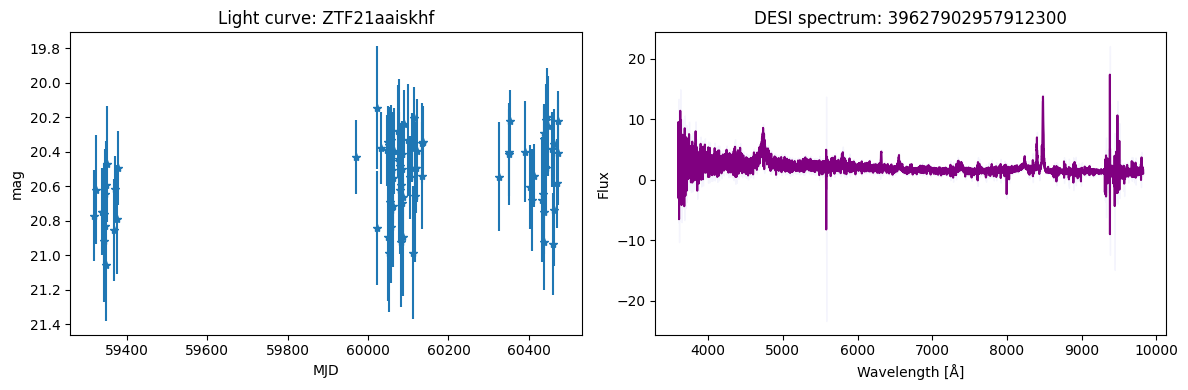

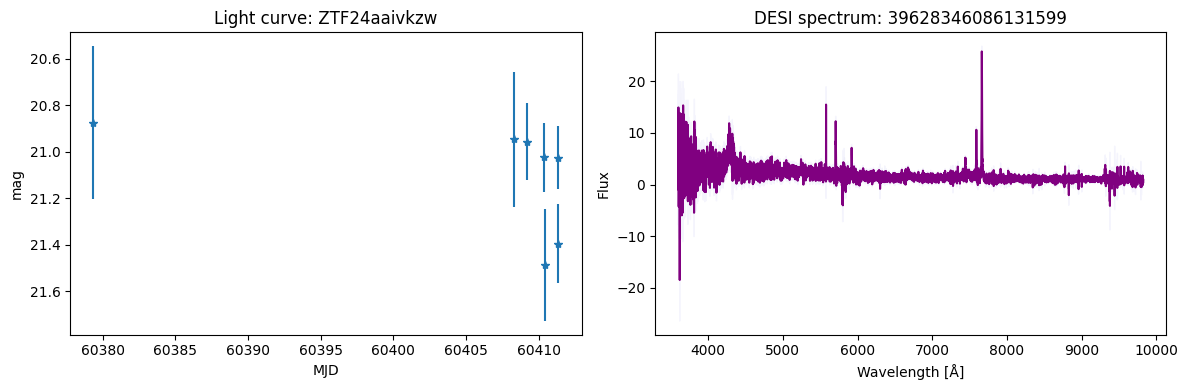

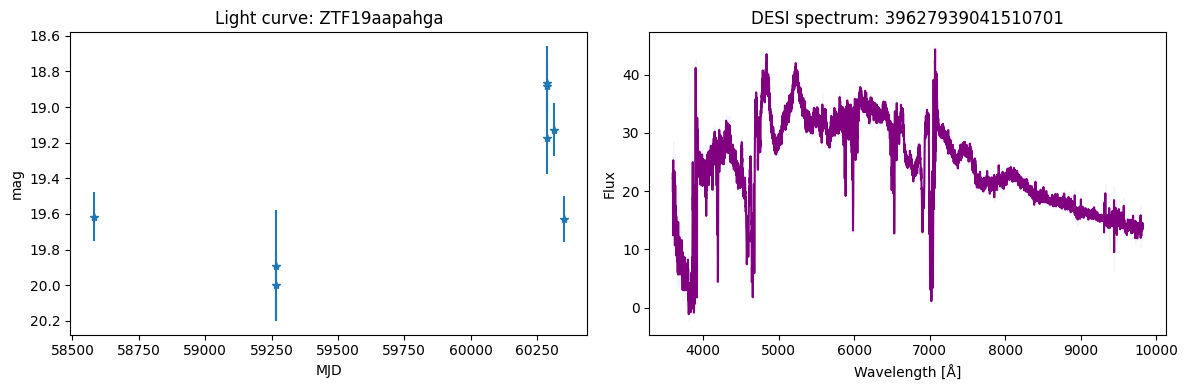

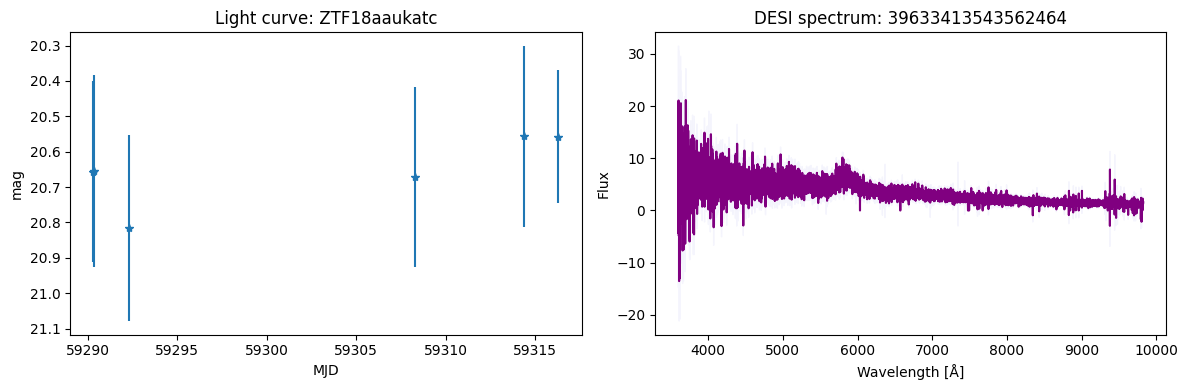

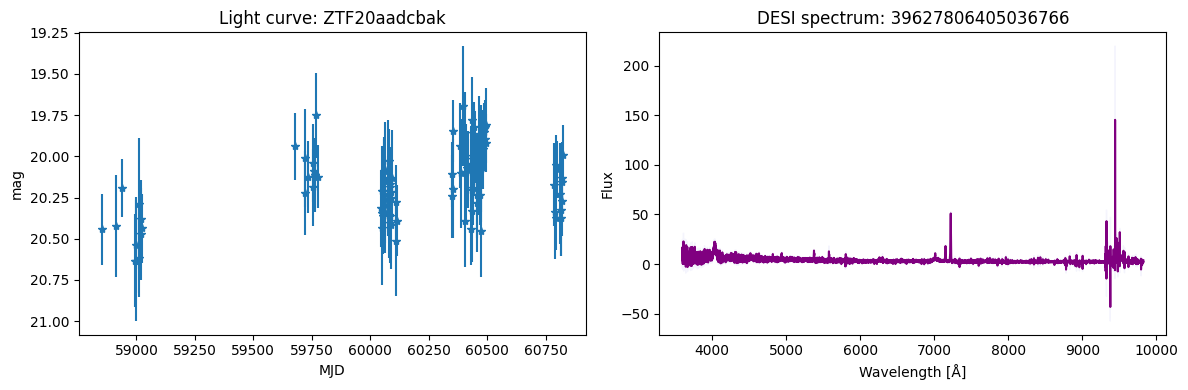

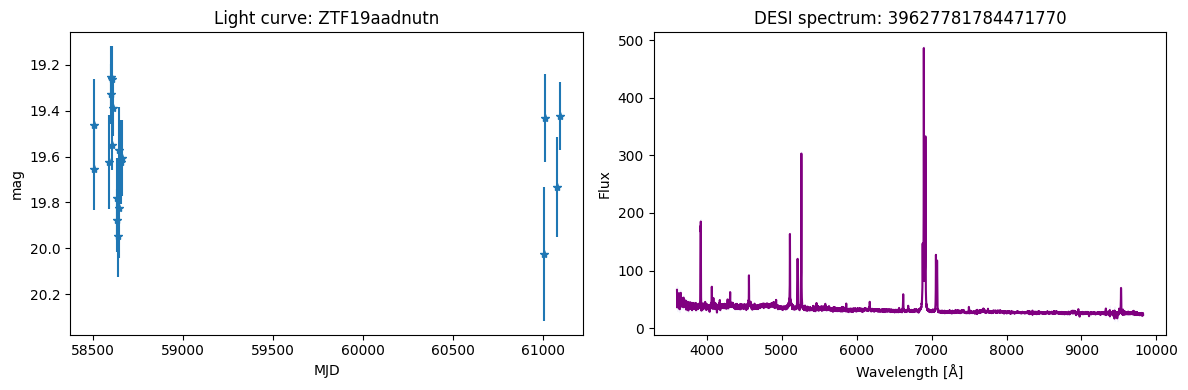

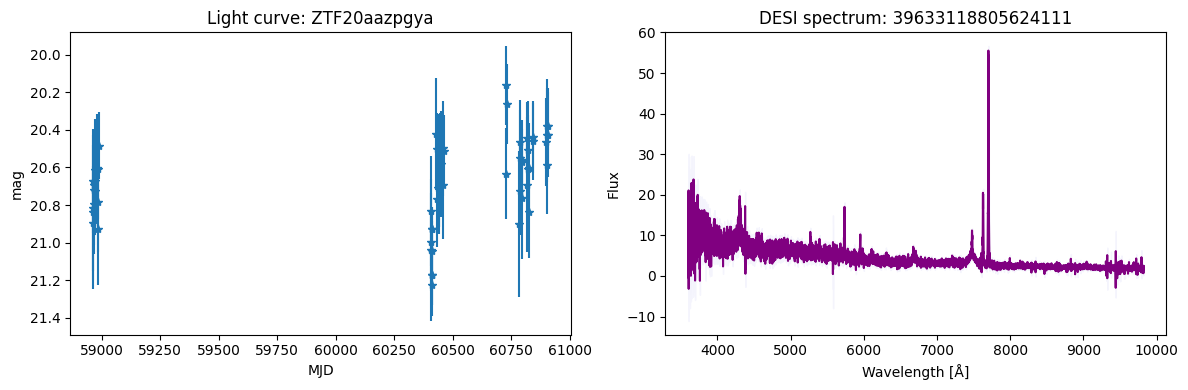

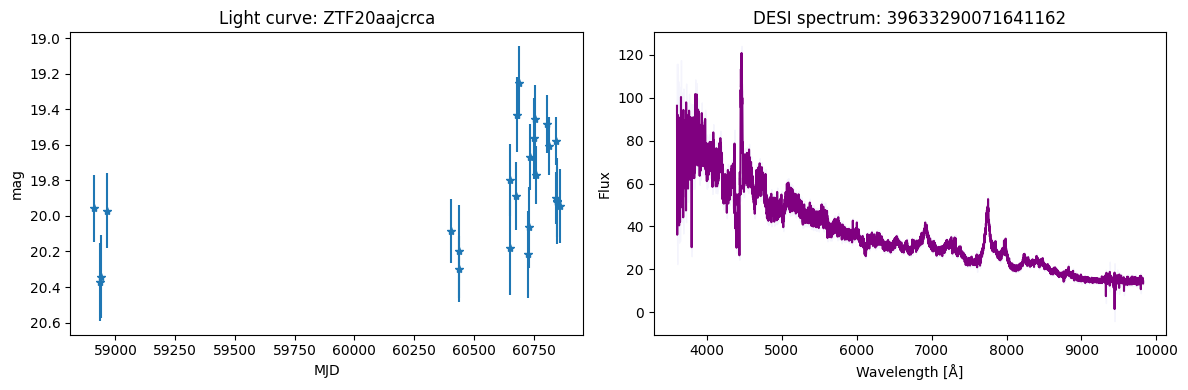

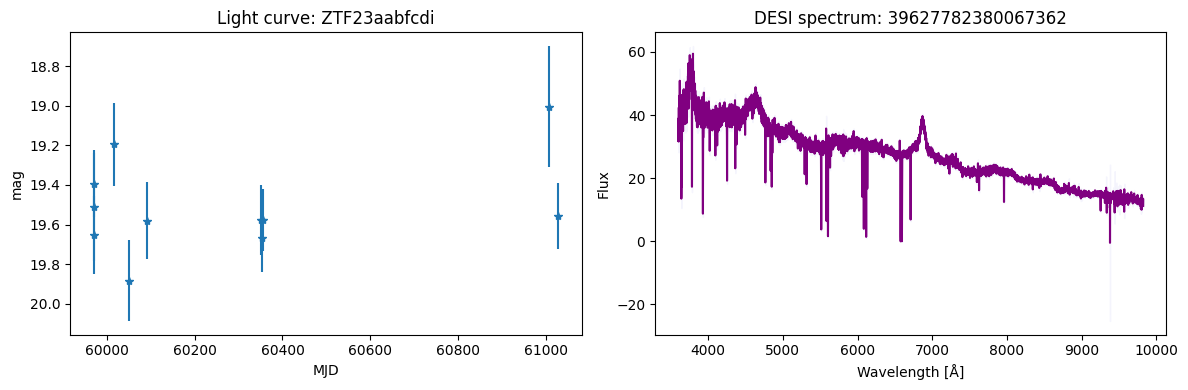

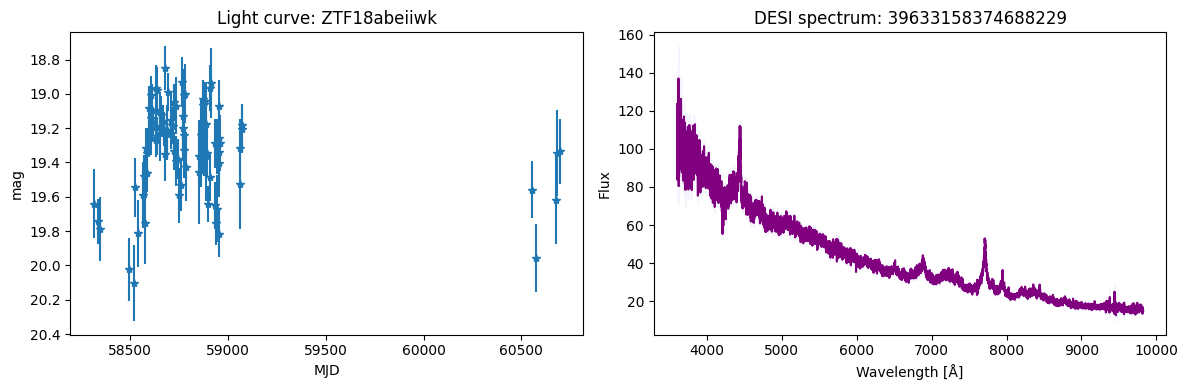

In [11]:
# ==============================
# Loop through all objects
# ==============================
results = []

for idx, row in objects.iterrows():
    tid = row['TARGETID']
    oid = row['oid']
    z = row['redshift']
    
    # ----- Light curve -----
    try:
        lc = alerce_client.query_detections(oid, format='pandas')
        amp, std = compute_variability(lc)
    except Exception:
        lc = pd.DataFrame()
        amp, std = np.nan, np.nan
    
    # ----- Spectrum -----
    wave, flux, sigma = get_spectrum(tid)
    
    # ----- Measure peak fluxes -----
    peaks = {}
    for line in LINES:
        peaks[line] = measure_line_peak(wave, flux, z, line)
    
    # ----- Side-by-side plot -----
    fig, axs = plt.subplots(1,2, figsize=(12,4))
    
    # Light curve
    if not lc.empty:
        axs[0].errorbar(lc.mjd, lc.magpsf, yerr=lc.sigmapsf, fmt='*')
        axs[0].invert_yaxis()
    axs[0].set_xlabel('MJD')
    axs[0].set_ylabel('mag')
    axs[0].set_title(f'Light curve: {oid}')
    
    # Spectrum
    if wave is not None:
        axs[1].plot(wave, flux, color='purple')
        if sigma is not None:
            axs[1].fill_between(wave, flux-sigma, flux+sigma, color='lavender', alpha=0.4)
        axs[1].set_xlabel('Wavelength [Å]')
        axs[1].set_ylabel('Flux')
        axs[1].set_title(f'DESI spectrum: {tid}')
    
    plt.tight_layout()
    plt.show()
    
    # ----- Collect results -----
    result_row = {'TARGETID': tid, 'amplitude': amp, 'stddev': std}
    result_row.update(peaks)
    results.append(result_row)


In [ ]:
# ==============================
# Summary table
# ==============================
summary_df = pd.DataFrame(results)
summary_df = objects.merge(summary_df, on='TARGETID', how='left')
display(summary_df)

In [ ]:
# ==============================
# Overlay all spectra for comparison
# ==============================
plt.figure(figsize=(12,5))

for tid in objects['TARGETID']:
    wave, flux, sigma = get_spectrum(tid)
    if wave is not None:
        plt.plot(wave, flux, lw=1, label=f'TARGETID {tid}')

plt.xlabel("Wavelength [Å]")
plt.ylabel("Flux [10⁻¹⁷ erg cm⁻² s⁻¹ Å⁻¹]")
plt.title("Overlay of DESI spectra for comparison")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# ==============================
# Imports
# ==============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from alerce.core import Alerce
from sparcl.client import SparclClient
import warnings

# ==============================
# Initialize clients
# ==============================
alerce_client = Alerce()
sparcl_client = SparclClient()

# ==============================
# Objects: TARGETIDs + ZTF OIDs + Redshifts
# ==============================
objects = pd.DataFrame({
    'TARGETID': [
        39627764151619120, 39633408468454516, 39627902957912300,
        39628346086131599, 39627939041510701, 39633413543562464,
        39627806405036766, 39627781784471770, 39633118805624111,
        39633290071641162, 39627782380067362, 39633158374688229
    ],
    'oid': [
        "ZTF20abeojsh", "ZTF19aapfxkt", "ZTF21aaiskhf", "ZTF24aaivkzw",
        "ZTF19aapahga", "ZTF18aaukatc", "ZTF20aadcbak", "ZTF19aadnutn",
        "ZTF20aazpgya", "ZTF20aajcrca", "ZTF23aabfcdi", "ZTF18abeiiwk"
    ],
    'redshift': [
        0.05, 0.12, 0.08, 0.10, 0.07, 0.15, 0.06, 0.09, 0.11, 0.14, 0.05, 0.08
    ]
})

# ==============================
# Emission lines and windows
# ==============================
LINES = {'Hα': 6563, 'Hβ': 4861, '[O III]': 5007}
WINDOW = 10  # +/- 10 Å

# ==============================
# Functions
# ==============================
def compute_variability(lc_df):
    mags = lc_df['magpsf'].values
    if len(mags) == 0:
        return np.nan, np.nan
    amplitude = np.max(mags) - np.min(mags)
    stddev = np.std(mags)
    return amplitude, stddev

def get_spectrum(targetid):
    res = sparcl_client.find(outfields=['sparcl_id'], constraints={'targetid':[targetid]}, limit=1)
    if len(res.ids) == 0:
        return None, None, None
    spec = sparcl_client.retrieve([res.ids[0]], include=['flux','ivar','wavelength','wavemin','wavemax','wave_sigma'])
    rec = spec.records[0]
    flux = np.array(rec['flux'])
    ivar = np.array(rec['ivar'])
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        sigma = np.where(ivar > 0, 1/np.sqrt(ivar), np.nan)
    if 'wavelength' in rec:
        wave = np.array(rec['wavelength'])
    else:
        wave = np.arange(rec['wavemin'], rec['wavemax'], rec['wave_sigma'])[:len(flux)]
    return wave, flux, sigma

def measure_line_peak_and_snr(wave, flux, sigma, redshift, line_name):
    """
    Returns peak flux and peak SNR of a given emission line.
    """
    if wave is None or flux is None or sigma is None:
        return np.nan, np.nan
    obs_wave = LINES[line_name] * (1 + redshift)
    mask = (wave > obs_wave - WINDOW) & (wave < obs_wave + WINDOW)
    if not np.any(mask):
        return np.nan, np.nan
    peak_flux = flux[mask].max()
    # SNR at the peak
    peak_index = np.argmax(flux[mask])
    peak_snr = peak_flux / sigma[mask][peak_index] if sigma[mask][peak_index] > 0 else np.nan
    return peak_flux, peak_snr

# ==============================
# Loop through all objects
# ==============================
results = []

for idx, row in objects.iterrows():
    tid = row['TARGETID']
    oid = row['oid']
    z = row['redshift']

    # ----- Light curve -----
    try:
        lc = alerce_client.query_detections(oid, format='pandas')
        amp, std = compute_variability(lc)
    except Exception:
        lc = pd.DataFrame()
        amp, std = np.nan, np.nan

    # ----- Spectrum -----
    wave, flux, sigma = get_spectrum(tid)

    # ----- Measure peak fluxes and SNRs -----
    line_metrics = {}
    for line in LINES:
        peak_flux, peak_snr = measure_line_peak_and_snr(wave, flux, sigma, z, line)
        line_metrics[f'{line}_peak_flux'] = peak_flux
        line_metrics[f'{line}_SNR'] = peak_snr

    # ----- Side-by-side plot -----
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))

    # Light curve
    if not lc.empty:
        axs[0].errorbar(lc.mjd, lc.magpsf, yerr=lc.sigmapsf, fmt='*')
        axs[0].invert_yaxis()
    axs[0].set_xlabel('MJD')
    axs[0].set_ylabel('mag')
    axs[0].set_title(f'Light curve: {oid}')

    # Spectrum
    if wave is not None:
        axs[1].plot(wave, flux, color='purple')
        if sigma is not None:
            axs[1].fill_between(wave, flux - sigma, flux + sigma, color='lavender', alpha=0.4)
        axs[1].set_xlabel('Wavelength [Å]')
        axs[1].set_ylabel('Flux')
        axs[1].set_title(f'Spectrum: {tid}')

    plt.tight_layout()
    plt.show()

    # ----- Collect results -----
    result_row = {'TARGETID': tid, 'amplitude': amp, 'stddev': std}
    result_row.update(line_metrics)
    results.append(result_row)

# Convert results to DataFrame
results_df = pd.DataFrame(results)
print(results_df)


In [ ]:
# ==============================
# Imports
# ==============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from alerce.core import Alerce
import warnings

# ==============================
# Initialize Alerce client
# ==============================
alerce_client = Alerce()

# Try to initialize SPARCL client; skip if unavailable
try:
    from sparcl.client import SparclClient
    sparcl_client = SparclClient()
except Exception as e:
    print(f"Warning: SPARCL client unavailable: {e}")
    sparcl_client = None

# ==============================
# Objects: TARGETIDs + ZTF OIDs + Redshifts
# ==============================
objects = pd.DataFrame({
    'TARGETID': [
        39627764151619120, 39633408468454516, 39627902957912300,
        39628346086131599, 39627939041510701, 39633413543562464,
        39627806405036766, 39627781784471770, 39633118805624111,
        39633290071641162, 39627782380067362, 39633158374688229
    ],
    'oid': [
        "ZTF20abeojsh", "ZTF19aapfxkt", "ZTF21aaiskhf", "ZTF24aaivkzw",
        "ZTF19aapahga", "ZTF18aaukatc", "ZTF20aadcbak", "ZTF19aadnutn",
        "ZTF20aazpgya", "ZTF20aajcrca", "ZTF23aabfcdi", "ZTF18abeiiwk"
    ],
    'redshift': [
        0.05, 0.12, 0.08, 0.10, 0.07, 0.15, 0.06, 0.09, 0.11, 0.14, 0.05, 0.08
    ]
})
